# Credict Card Customer segmentation

## Business Problem
Credit card customers have different spending and payment habits. Treating all customers the same may not be effective for banks. By identifying customers with similar financial behavior, banks can better understand their customers and provide more personalized services.

## Project Objective

The objective of this project is to group credit card customers into meaningful segments based on their usage behavior using unsupervised learning techniques. These customer segments can help banks improve marketing strategies, customer engagement, and business decision-making.




The EDA will include:

- Understanding the dataset and its features.
- Checking data types, missing values, and duplicates.
- Exploring the distribution of numerical features.
- Detecting outliers.
- Analyzing correlations between variables.
- Summarizing key insights to guide data preprocessing and clustering.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
df = pd.read_csv("../data/raw/CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.shape

(8950, 18)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

## Statistical Summary

In [5]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Null Values

In [6]:
df.isnull().sum().sort_values(ascending=False)

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
BALANCE                               0
CUST_ID                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_TRX                         0
PAYMENTS                              0
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

**Observation:** MINIMUM_PAYMENTS is missing in 313 rows (~3.5%) and
CREDIT_LIMIT in 1 row (~0.01%). Both are low enough to impute rather than drop — median imputation is preferred over mean since both columns are heavily right-skewed.

## Duplicate Values

In [7]:
df.duplicated().sum()

np.int64(0)

**Observation:** No duplicate rows found.

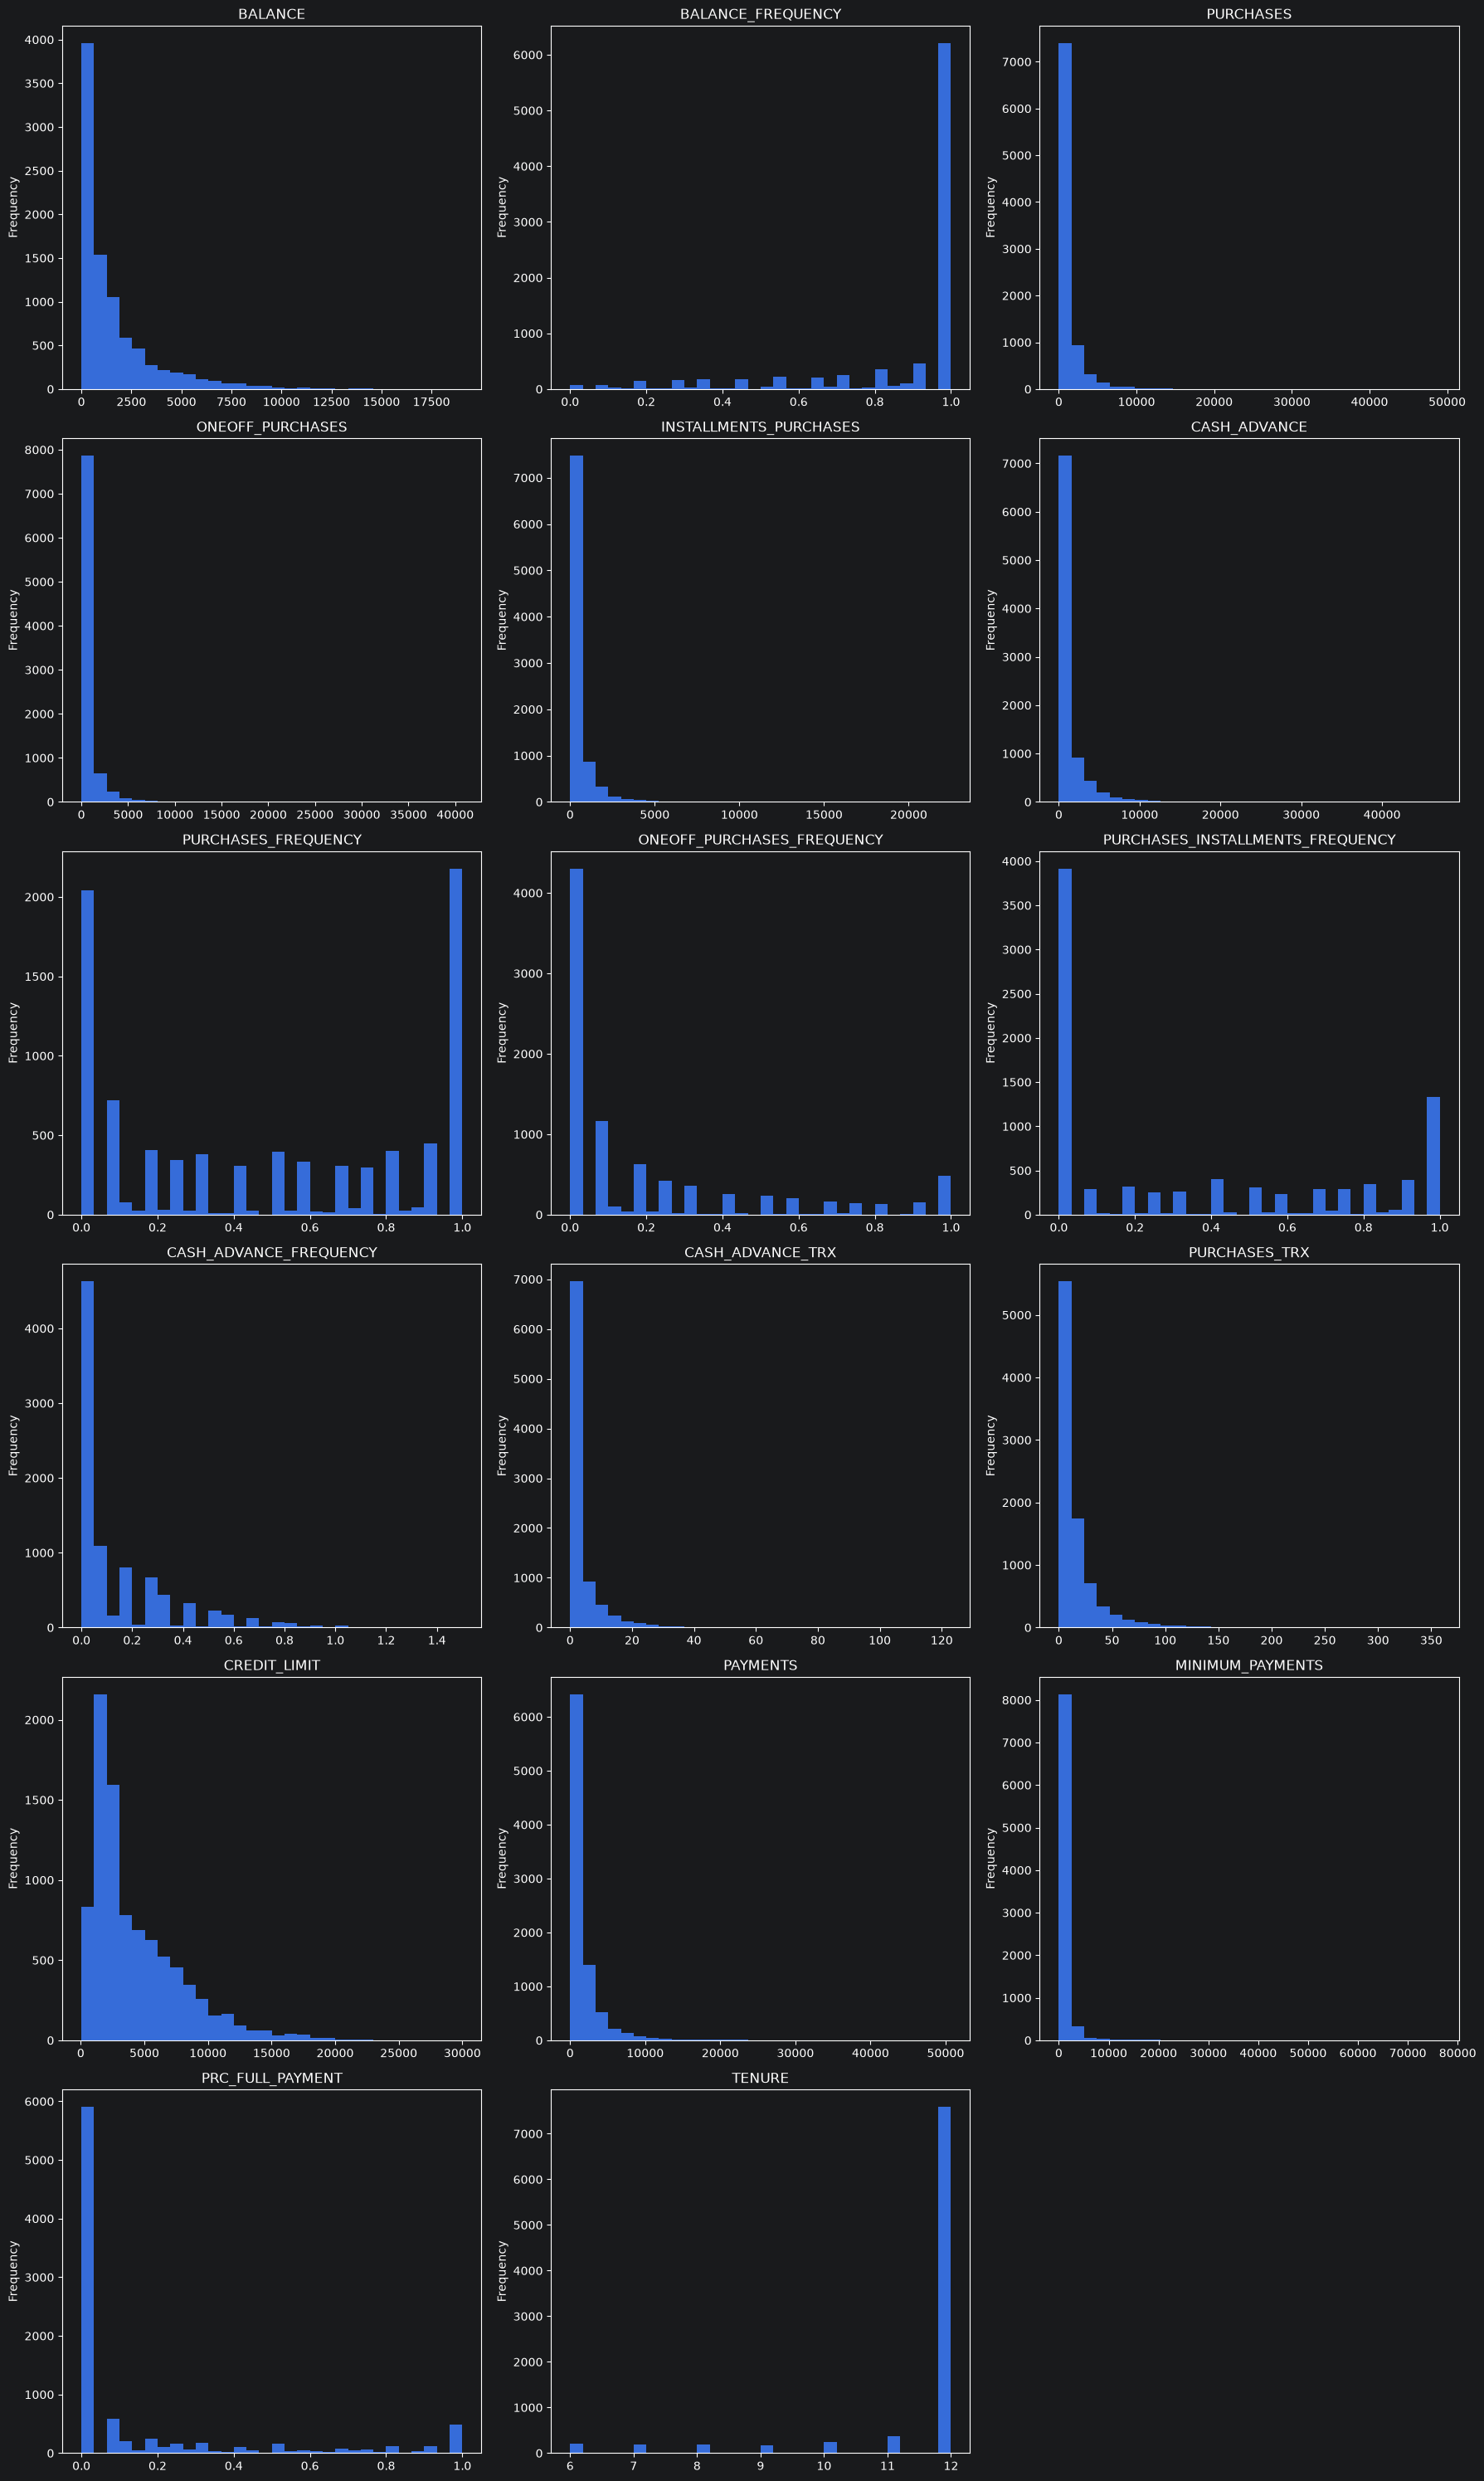

In [8]:
import math

# Select numerical columns
num_cols = df.select_dtypes(include=['number']).columns

# Set subplot
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observation:** Most numeric features are highly right-skewed with zero-inflated distributions, except the frequency-based columns (bimodal/polarized) and TENURE (negatively skewed, near-categorical) — indicating log transformation is appropriate for monetary columns but not universally across the dataset.

## Outlier Detection

In [9]:
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": count,
        "Outlier %": round(count / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values(by="Outlier %", ascending=False)

,Feature,Outlier Count,Outlier %
1,BALANCE_FREQUENCY,1493,16.68
15,PRC_FULL_PAYMENT,1474,16.47
16,TENURE,1366,15.26
5,CASH_ADVANCE,1030,11.51
3,ONEOFF_PURCHASES,1013,11.32
4,INSTALLMENTS_PURCHASES,867,9.69
14,MINIMUM_PAYMENTS,841,9.40
13,PAYMENTS,808,9.03
2,PURCHASES,808,9.03
10,CASH_ADVANCE_TRX,804,8.98


**Observation:** The IQR method flags a high outlier % for BALANCE_FREQUENCY (16.68%), PRC_FULL_PAYMENT (16.47%), and TENURE (15.26%). This does not mean these columns have genuine anomalies — IQR performs poorly on bounded (0-1), near-categorical, or heavily skewed-toward-one-value features like these. For TENURE, most customers sit at the max value (12), so the 15% flagged as "outliers" are simply the minority with shorter tenure, not errors. Treat these three columns differently from true continuous monetary outliers.

C:\Users\USER\AppData\Local\Temp\ipykernel_14096\565817439.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_14096\565817439.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_14096\565817439.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_14096\565817439.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'verti

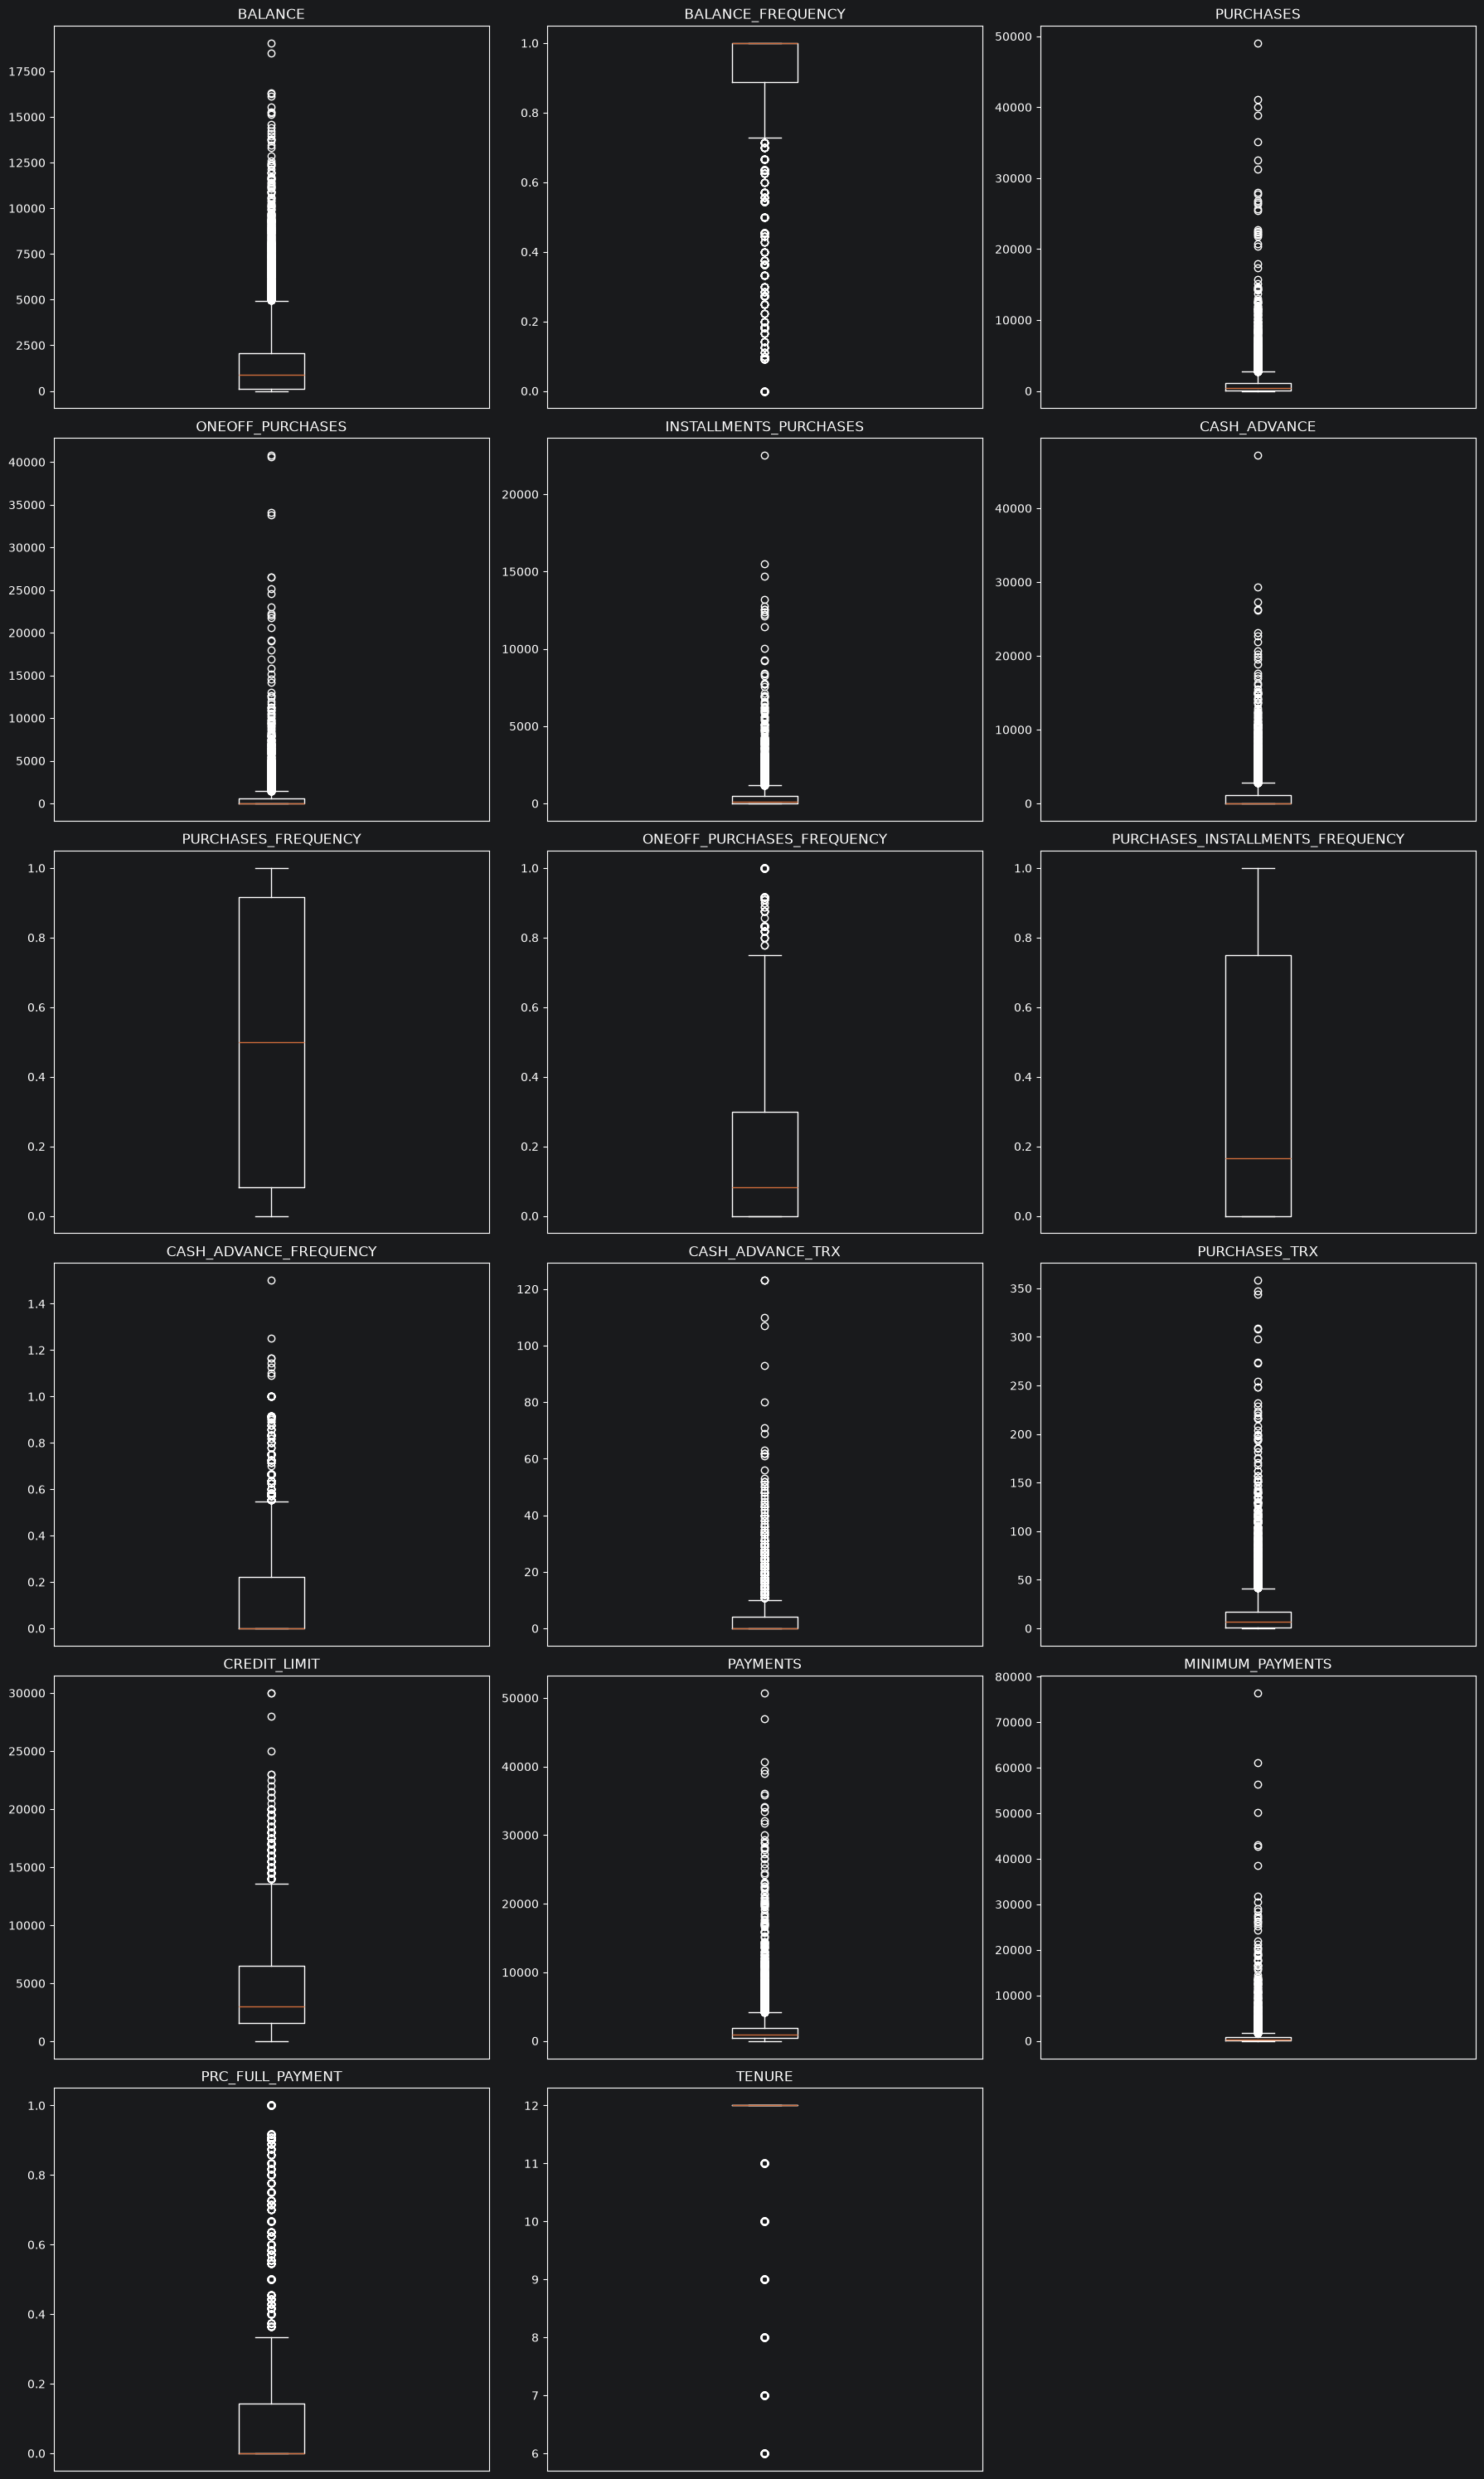

In [10]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel("")
    axes[i].set_xticks([])

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Boxplots confirm the skewness identified in the histograms. Monetary columns (BALANCE, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PAYMENTS, MINIMUM_PAYMENTS) show heavily compressed IQR boxes with long chains of outliers extending far beyond the whiskers — these are not data errors but genuine high-spending customers, so outliers should be treated via transformation/capping rather than blindly deleted. Frequency-based columns (PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY) are comparatively well-distributed with fewer outlier concerns. TENURE shows almost no variance, with most customers at the maximum value, making its 'outliers' actually a minority behavioral group rather than noise.

## Skewness Check

In [11]:
skew_vals = df[num_cols].skew().sort_values(ascending=False)
skew_vals

MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64

**Observation:** This confirms the visual skew seen in the histograms. MINIMUM_PAYMENTS (~13.6), ONEOFF_PURCHASES (~10.0), and PURCHASES (~8.1) have the most extreme right-skew and are the strongest candidates for a log1p transform before scaling/clustering. BALANCE_FREQUENCY (~-2.0) and TENURE (~-2.9) are negatively skewed instead — log transform won't help these; they need separate handling (e.g. treat TENURE as near-categorical).

## Correlation Heatmap

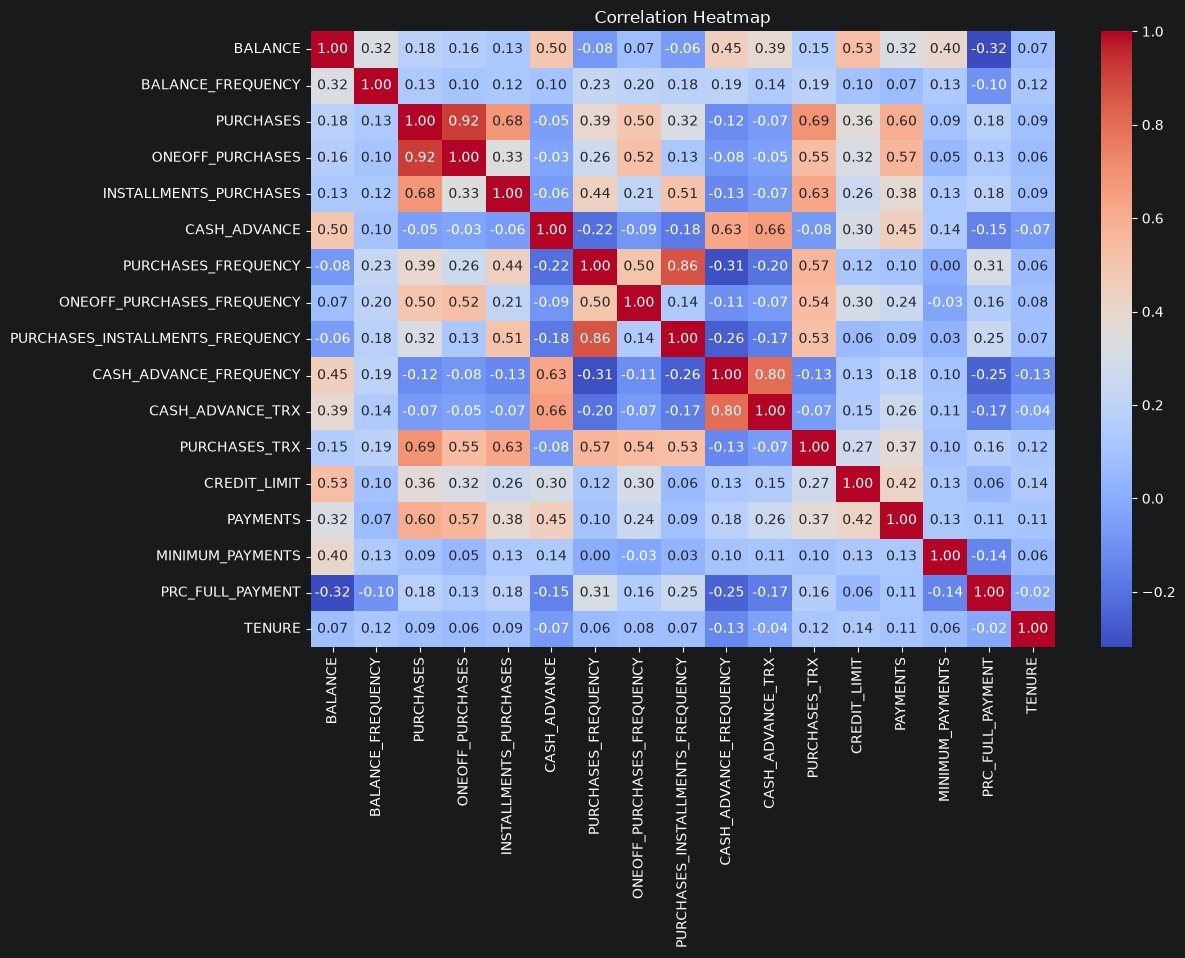

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Observations
- PURCHASES and ONEOFF_PURCHASES show a very strong positive correlation (0.92), indicating that customers with higher total purchases also tend to make more one-time purchases.
- PURCHASES_FREQUENCY and PURCHASES_INSTALLMENTS_FREQUENCY have a strong positive correlation (0.86), suggesting that customers who purchase frequently also tend to make installment purchases more often.
- CASH_ADVANCE_FREQUENCY and CASH_ADVANCE_TRX are highly correlated (0.80), indicating that customers who frequently take cash advances also perform more cash advance transactions.
- PURCHASES is positively correlated with PURCHASES_TRX (0.69) and INSTALLMENTS_PURCHASES (0.68), showing that higher spending is generally associated with more purchase transactions and installment purchases.
- BALANCE has a moderate positive correlation with CREDIT_LIMIT (0.53) and CASH_ADVANCE (0.50), suggesting that customers with higher balances often have higher credit limits and use cash advances more.
- PAYMENTS shows a moderate positive correlation with PURCHASES (0.60), indicating that customers who spend more generally make larger payments.
- TENURE shows weak correlation (mostly below 0.15) with almost all other features, behaving nearly independently of spending patterns.
- Several feature groups (purchases-related, cash-advance-related) show internal redundancy, indicating multicollinearity that should be addressed via PCA or feature selection before clustering

## Feature Engineering

Feature engineering was performed to create additional variables that better represent customer spending behavior, credit utilization, and payment patterns. These engineered features provide more meaningful information for clustering than the original features alone.

| Feature              | Description                                   |
| -------------------- | --------------------------------------------- |
| ONEOFF_RATIO         | Ratio of one-off purchases to total purchases |
| LIMIT_USAGE          | Ratio of account balance to credit limit      |
| PAYMENT_RATIO        | Ratio of payments to minimum payments         |
| MONTHLY_PURCHASE     | Average monthly purchase amount               |
| MONTHLY_CASH_ADVANCE | Average monthly cash advance                  |


In [13]:
from src.feature_engineering import add_features

df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(
    df["MINIMUM_PAYMENTS"].median()
)

df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(
    df["CREDIT_LIMIT"].median()
)

df_features = add_features(df)

df_features.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,ONEOFF_RATIO,LIMIT_USAGE,PAYMENT_RATIO,MONTHLY_PURCHASE,MONTHLY_CASH_ADVANCE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,...,1000.0,201.802084,139.509787,0.000000,12,0.000000,0.040860,1.436214,7.950000,0.000000
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,...,7000.0,4103.032597,1072.340217,0.222222,12,0.000000,0.457430,3.822677,0.000000,536.912124
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,...,7500.0,622.066742,627.284787,0.000000,12,0.998708,0.332642,0.990103,64.430833,0.000000
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,...,7500.0,0.000000,312.343947,0.000000,12,0.999333,0.222193,0.000000,124.916667,17.149001
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,...,1200.0,678.334763,244.791237,0.000000,12,0.941176,0.680861,2.759800,1.333333,0.000000


## Data Preprocessing

Before clustering, the dataset was preprocessed to improve data quality and ensure all features were on a comparable scale.

The preprocessing pipeline included:

- Dropping the customer ID column
- Median imputation for missing values
- Outlier treatment using the IQR method
- Log transformation for highly skewed features
- Standardization using StandardScaler

In [14]:
from src.preprocessing import create_preprocessing_pipeline

preprocessing_pipeline = create_preprocessing_pipeline()

X_processed = preprocessing_pipeline.fit_transform(df_features)

X_processed.shape

(8950, 22)

## Determining the Optimal Number of Clusters

The optimal number of clusters for K-Means was determined using:

Elbow Method
Silhouette Score

Based on these methods, 4 clusters were selected for further analysis.

In [15]:
from src.clustering import find_optimal_k, plot_elbow_and_silhouette

k_values, inertia, silhouette = find_optimal_k(X_processed)

plot_elbow_and_silhouette(
    k_values,
    inertia,
    silhouette
)

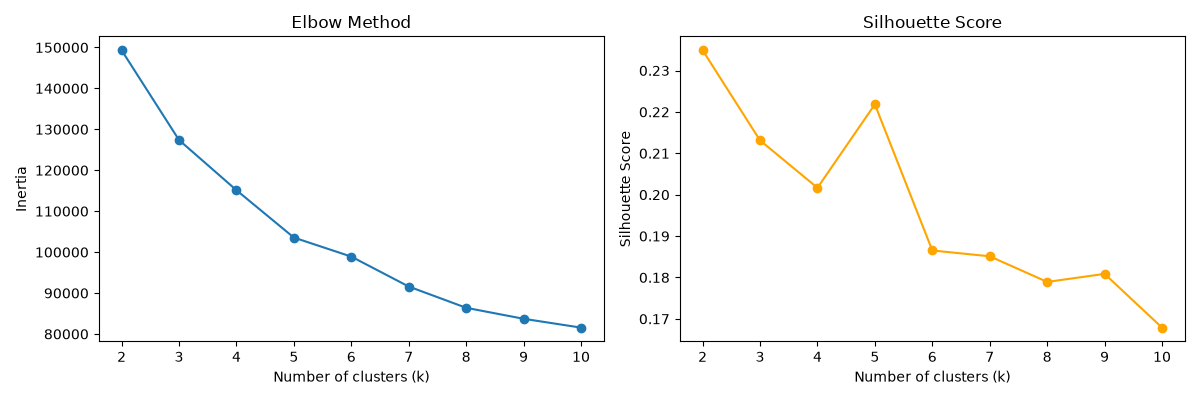

In [16]:
from IPython.display import Image, display

display(Image(filename="../outputs/reports/elbow_silhouette.png"))

The elbow point and silhouette score indicate that 4 clusters provide a suitable balance between cluster compactness and separation.

## Clustering Algorithms

The following clustering algorithms were applied to segment customers:

- K-Means
- Hierarchical Clustering
- Gaussian Mixture Model (GMM)
- DBSCAN

In [17]:
from src.clustering import run_clustering

results = run_clustering(
    X_processed,
    n_clusters=4
)

## Cluster Evaluation

The clustering algorithms were evaluated using:

- Silhouette Score
- Davies–Bouldin Index

Higher Silhouette Scores and lower Davies–Bouldin Index values indicate better clustering performance.

In [18]:
from src.clustering import evaluate_models

scores_df = evaluate_models(
    X_processed,
    results
)

scores_df

,n_clusters_found,silhouette_score,davies_bouldin_score
model,,,
kmeans,4,0.201668,1.696794
hierarchical,4,0.155949,1.784761
gmm,4,0.171629,2.020715
dbscan,3,0.084245,2.691098


- Among all clustering algorithms, K-Means achieved the highest Silhouette Score and the lowest Davies–Bouldin Index, indicating better cluster quality.

## Cluster Visualization

Principal Component Analysis (PCA) was used to reduce the dimensionality of the processed data to two dimensions for visualization purposes.

In [19]:
from src.clustering import plot_clusters_pca

best_labels = results["kmeans"][1]

plot_clusters_pca(
    X_processed,
    best_labels
)

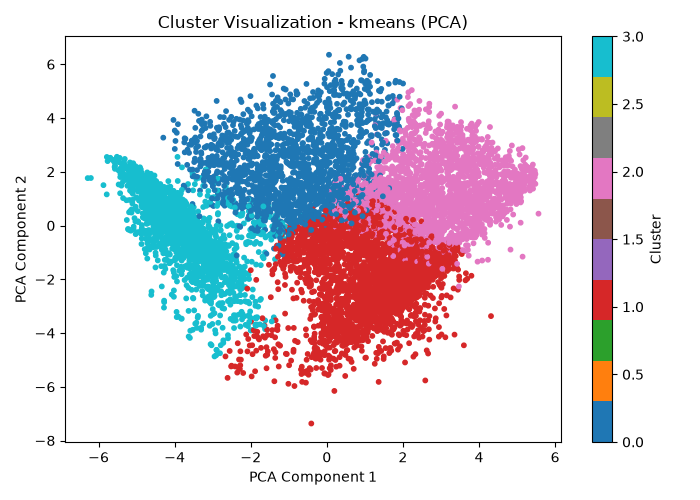

In [20]:
from IPython.display import Image, display

display(Image(filename="../outputs/reports/cluster_pca_plot.png"))

## Cluster Size Distribution

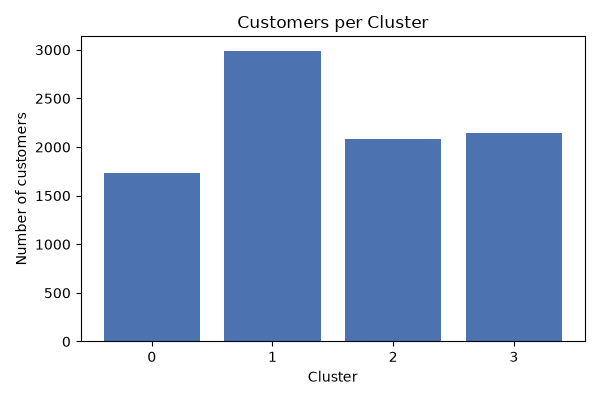

In [21]:
from src.clustering import plot_cluster_sizes

plot_cluster_sizes(best_labels)

display(Image(filename="../outputs/reports/cluster_sizes.png"))

- The customer base is distributed across four clusters, with Cluster 1 containing the largest number of customers.

## Cluster Profile

The mean values of numerical features were calculated for each cluster to understand customer behavior.

In [22]:
from src.clustering import profile_clusters

cluster_profile = profile_clusters(
    df_features.drop(columns=["CUST_ID"]),
    best_labels
)

cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,ONEOFF_RATIO,LIMIT_USAGE,PAYMENT_RATIO,MONTHLY_PURCHASE,MONTHLY_CASH_ADVANCE
CLUSTER,,,,,,,,,,,,,,,,,,,,,
0,3067.114420,0.969176,1030.291977,611.975272,418.576624,2465.657981,0.564138,0.251802,0.384438,0.323626,...,5259.653179,2428.655697,1461.112287,0.029881,11.432948,0.611793,0.631669,3.202112,90.812179,222.486455
1,336.309768,0.745188,416.716564,113.333677,303.789736,26.204051,0.546495,0.061959,0.469433,0.008772,...,3170.664676,658.956629,410.735558,0.234588,11.455336,0.285748,0.177223,6.756149,36.995799,2.453233
2,1437.724838,0.960893,2846.864701,1869.124509,978.187700,78.645344,0.842158,0.566683,0.566449,0.018453,...,6247.575564,2775.620686,751.404566,0.262299,11.827504,0.659273,0.275989,9.404911,240.905629,6.654563
3,2187.584014,0.905853,4.340345,1.856362,2.524538,1983.606067,0.010085,0.003972,0.005281,0.272824,...,4015.308401,1654.720794,1043.993186,0.035192,11.369869,0.040826,0.597032,5.519419,0.378842,182.010541


## Cluster Interpretation

The K-Means model (best performing, silhouette score 0.202) produced 4 customer segments.
Each cluster's mean feature values were compared across all 17
features to identify the behavior that defines it.

### Cluster 0 — Cash Advance Revolvers
- Highest cash advance usage (avg ₹2466) and highest cash advance frequency (0.32)
- High balance (₹3067), highest minimum payments (₹1461)
- Very low full-payment rate (0.03) — rarely clears their balance

**Interpretation:** Customers who primarily use their card for cash withdrawals and carry
a revolving balance. High interest revenue for the bank, but higher credit risk.

### Cluster 1 — Low Engagement / Inactive
- Lowest balance (₹336), lowest cash advance, lowest purchase transactions (8.9)
- Lowest credit limit (₹3171) and lowest payments overall
- Lower balance update frequency (0.75) than every other cluster

**Interpretation:** Largely dormant cardholders with minimal activity across the board.
Low revenue, low risk — candidates for re-engagement campaigns rather than premium offers.

### Cluster 2 — Premium Active Customers
- Highest purchases (₹2847), highest purchase frequency (0.84), highest purchase
  transactions (36.3)
- Highest full-payment rate (0.26) and highest credit limit (₹6248)
- Very low cash advance usage (₹79)

**Interpretation:** The bank's ideal segment — high spending, high engagement, and
consistently pays in full. Low risk, high value. Good target for premium rewards or
loyalty programs.

### Cluster 3 — Cash-Only Users
- Near-zero purchase activity (purchase frequency 0.01, purchase transactions 0.12)
- Still uses cash advances heavily (₹1984, second-highest)
- High balance (₹2188), low full-payment rate (0.035)

**Interpretation:** Distinct from Cluster 0 despite also relying on cash advances — this
group doesn't shop with the card at all, effectively using it as a cash-loan tool rather
than for purchases.



### Summary Table

| Cluster | Label | Key Traits | Business Meaning |
|---|---|---|---|
| 0 | Cash Advance Revolvers | High cash advance, high balance, low full-payment | High interest revenue, high risk |
| 1 | Low Engagement/Inactive | Lowest activity across almost every feature | Low value, re-engagement target |
| 2 | Responsible High Spenders | Highest purchases + highest full-payment rate | Ideal, low-risk, high-value customers |
| 3 | Cash-Only Users | Near-zero purchases, high cash advance | Uses card as a loan, not for shopping |



**Note on difference between Cluster 0 vs Cluster 3:**
both clusters rely heavily on cash
advances, and looking at CASH_ADVANCE alone could make them appear similar. What
separates them is PURCHASES_FREQUENCY (0.56 for Cluster 0 vs 0.01 for Cluster 3) —
Cluster 0 still shops moderately alongside taking cash advances, while Cluster 3 doesn't
shop at all. This cross-feature check was necessary to avoid merging two behaviorally
distinct segments.

## Business Recommendations

| Cluster                           | Recommendation                                                     |
| --------------------------------- | ------------------------------------------------------------------ |
| High Balance Revolvers            | Encourage higher repayments and provide debt management support.   |
| Low Activity Customers            | Increase engagement through cashback offers and rewards.           |
| Premium Active Customers          | Retain customers with premium cards and loyalty programs.          |
| Cash Withdrawal Focused Customers | Promote purchase-based usage and reduce reliance on cash advances. |


## Conclusion

This project segmented credit card customers using multiple clustering algorithms. After comparing K-Means, Hierarchical Clustering, Gaussian Mixture Models, and DBSCAN, K-Means produced the best clustering performance based on the Silhouette Score and Davies–Bouldin Index. The identified customer segments provide valuable insights into spending patterns, credit utilization, and payment behavior, enabling businesses to design targeted marketing strategies and improve customer relationship management.